In [1]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

load image


In [2]:
def read_file(filename):
   img = cv2.imread(filename) 
   img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
   plt.imshow(img)
   plt.show()
   return img

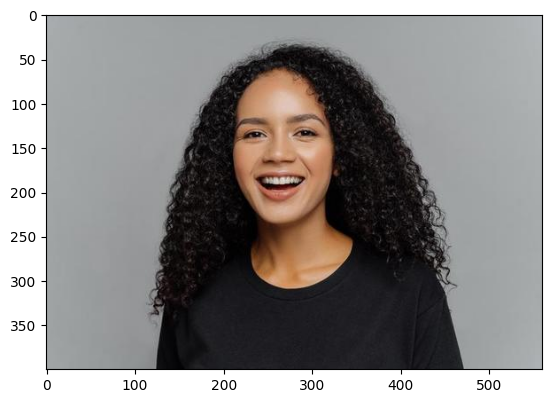

In [3]:
filename = "human_image.jpg"
img = read_file(filename)

org_img = np.copy(img)

create edge mask


In [4]:
def edge_mask(img , line_size ,blur_value):
    """input -input image
    output - edge of images
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray_blur = cv2.medianBlur(gray, blur_value)

    edges = cv2.adaptiveThreshold(gray_blur,255,cv2.ADAPTIVE_THRESH_MEAN_C , cv2.THRESH_BINARY, line_size, blur_value)
    return edges


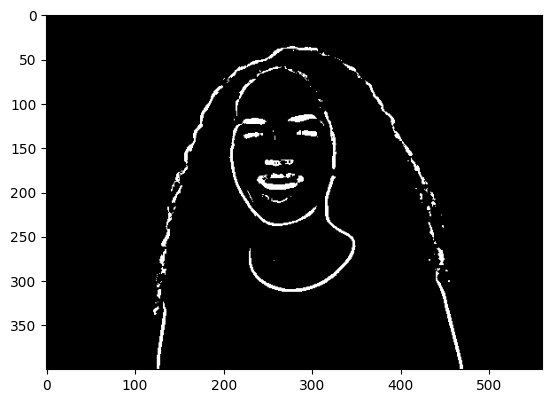

In [5]:
line_size , blur_value = 9,9
edges = edge_mask(img , line_size , blur_value)

plt.imshow(edges , cmap="binary")
plt.show()


# reduce the color pallate

In [6]:
def color_quantization(img , k):

    #transform the image
    data = np.float32(img).reshape((-1 ,3))

    #determine criteria
    criteria = (cv2.TermCriteria_EPS + cv2.TermCriteria_MAX_ITER , 20 , 0.001)

    #implementing k means 
    ret, label ,center = cv2.kmeans(data, k , None, criteria ,10,cv2.KMEANS_RANDOM_CENTERS)
    center = np.uint8(center)
    result = center[label.flatten()]
    result = result.reshape(img.shape)
    return result


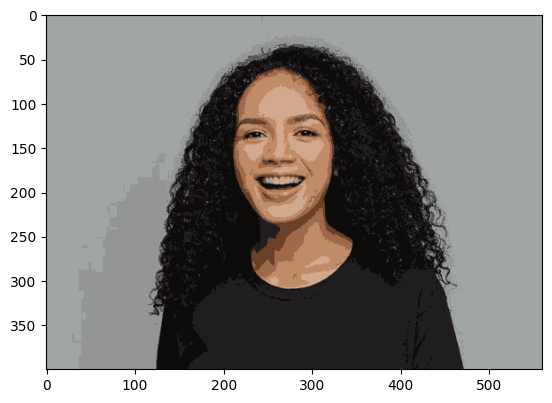

In [7]:
img = color_quantization(img , k=9)

plt.imshow(img)
plt.show()


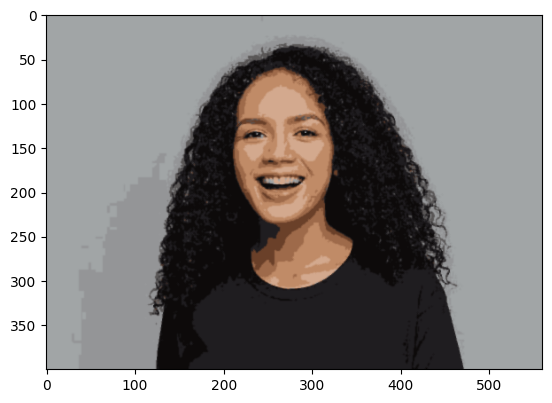

In [8]:
#reduce the noise

blurred = cv2.bilateralFilter(img ,d = 3 , sigmaColor = 200 ,sigmaSpace = 200)
plt.imshow(blurred)
plt.show()

#combine edge mask with the quantized image 

In [9]:
def cartoon():
    c = cv2.bitwise_and(blurred,blurred ,mask = edges )
    plt.imshow(c)
    plt.title("Cartoonified Image")
    plt.show()


    plt.imshow(org_img)
    plt.title("Orginal Image")
    plt.show()

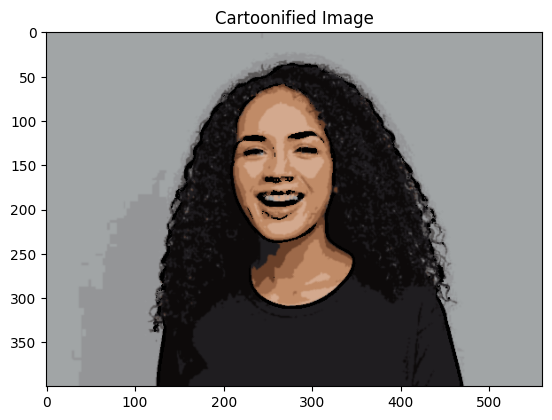

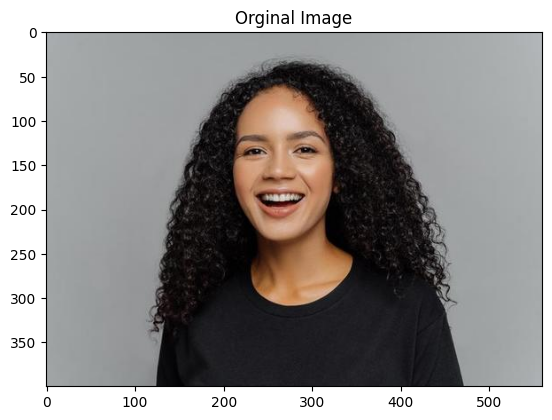

In [10]:
cartoon()